In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Mall_Customers.csv')

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Perform EDA

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum().sum()

0

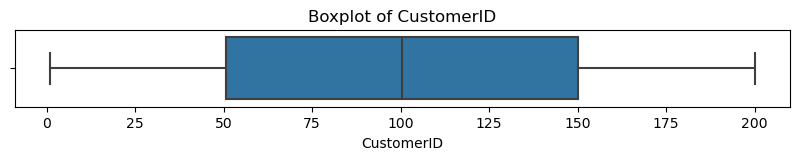

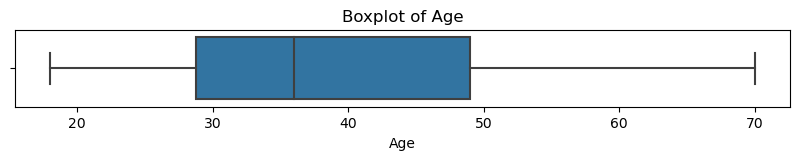

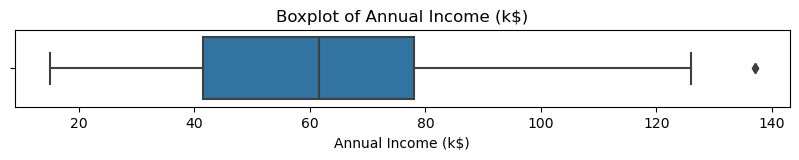

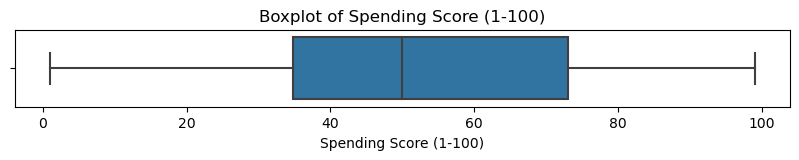

In [8]:
def boxplots(col):
    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
for col in df.select_dtypes(exclude=['object', 'category']).columns:
    boxplots(col)

In [9]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [10]:
df.shape

(200, 5)

# Q.2  It is general practice to encode the data before applying ML model. but, while performing clustering encoding should be avoided for binary-valued data?

Yes while permforming clustering encoding must be avoided for binary values to preserve the nature of binary data. Encoding can distort the similarity relationships among data points. That's why choosing an appropriate distance metric that handles binary values would be quite good.

# Q3. Show gender wise distribution of customers using histogram and pie chart. 
 

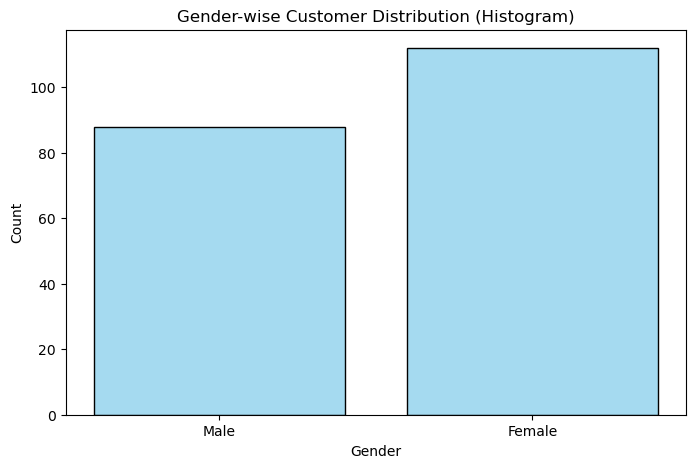

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Gender'], discrete=True, shrink=0.8, color="skyblue")
plt.title("Gender-wise Customer Distribution (Histogram)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [12]:
gender_counts=df['Gender'].value_counts()

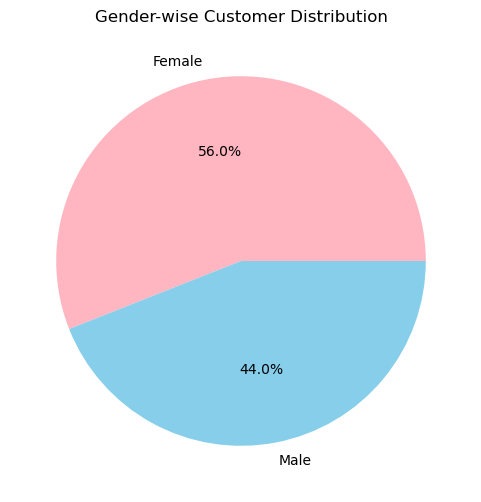

In [13]:
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightpink', 'skyblue'])
plt.title("Gender-wise Customer Distribution")
plt.show()

# Q4. Should standardization to be performed in case of clustering model? explain with reason
  


If standardization is performed it will not change the outcome or the way clusters are made. We do not predict anything here. therefore, there is no need of standardization 

# Q5. Compare average annual income and median annual income of the customers. 


In [14]:
avg_income=df["Annual Income (k$)"].mean()
avg_income

60.56

In [15]:
median_income=df["Annual Income (k$)"].median()
median_income

61.5

In [16]:
if(avg_income>median_income):
    print("")

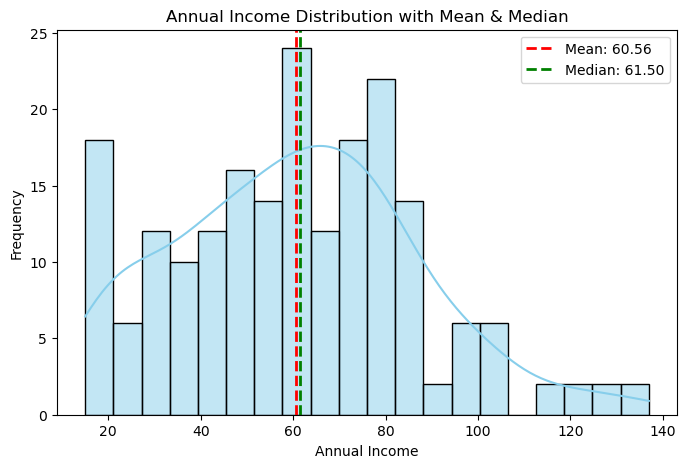

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True, color="skyblue")
plt.axvline(avg_income, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {avg_income:.2f}')
plt.axvline(median_income, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_income:.2f}')
plt.title("Annual Income Distribution with Mean & Median")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.legend()
plt.show()

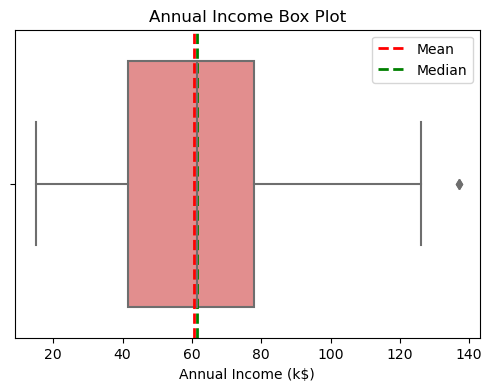

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Annual Income (k$)"], color="lightcoral")
plt.axvline(avg_income, color='red', linestyle='dashed', linewidth=2, label="Mean")
plt.axvline(median_income, color='green', linestyle='dashed', linewidth=2, label="Median")
plt.title("Annual Income Box Plot")
plt.legend()
plt.show()

# Q6. Create correlation matrix of numerical columns in the data 


In [19]:
num_df=df.select_dtypes(include=['number'])
num_df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [20]:
corr_matrix=num_df.corr()
corr_matrix

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


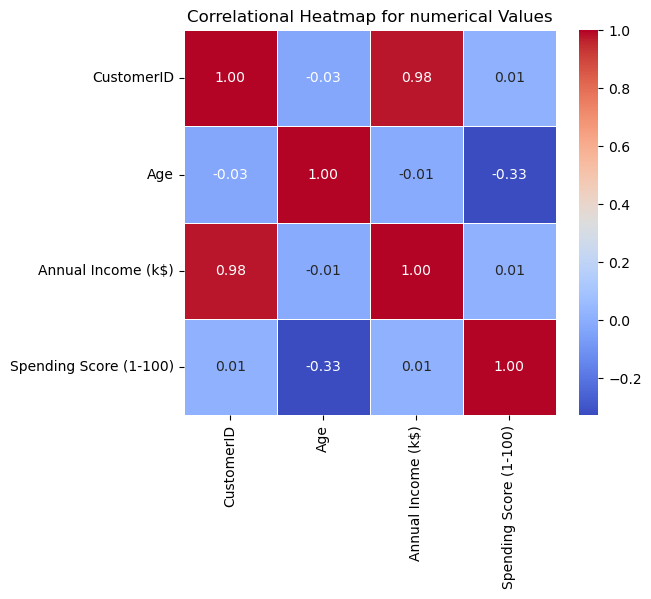

In [21]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Correlational Heatmap for numerical Values")
plt.show()

# Q7. Apply kmeans clustering on this dataset, find optimum clusters. 

In [22]:
from sklearn.cluster import KMeans

In [23]:
X=num_df

In [24]:
X

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [25]:
wcss=[]
k_range=range(1,11)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler=StandardScaler()

In [28]:
X_scaled=scaler.fit_transform(X)

In [30]:
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    

C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have

In [ ]:
# !pip install --upgrade threadpoolctl


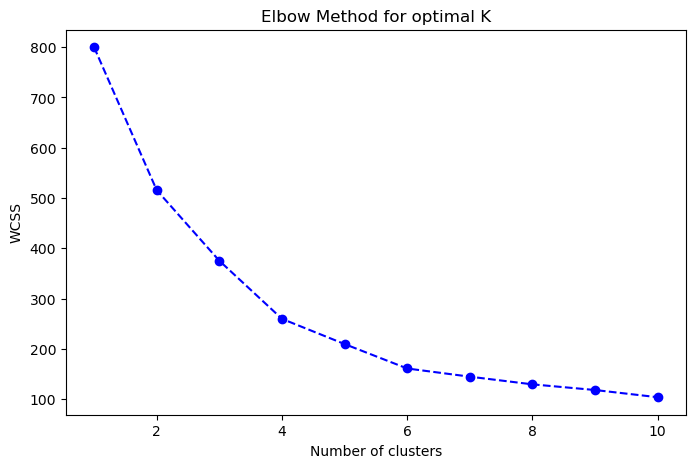

In [32]:
plt.figure(figsize=(8,5))
plt.plot(k_range,wcss, marker='o', linestyle='--',color='b')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for optimal K')
plt.show()

#  Q9. Label the clusters generated by k means clustering 


In [38]:
optimal_k=5
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['Cluster']= kmeans.fit_predict(X_scaled)

C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


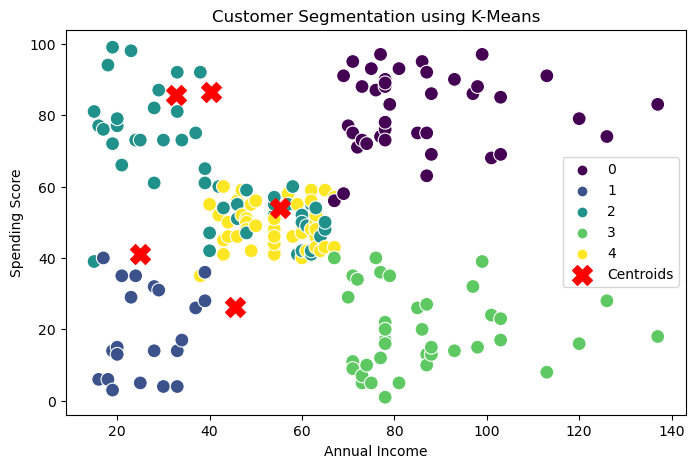

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=df["Cluster"], palette="viridis", s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],  # Rescaling centers
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c="red", marker="X", label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [42]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,32.731707,85.634146,80.902439
1,45.523810,26.285714,19.380952
2,25.038462,41.057692,62.788462
3,40.333333,86.487179,19.179487
4,55.255319,54.063830,49.000000


In [43]:
def label_clusters(row):
    if row["Cluster"] == 0:
        return "Low Income, Low Spend"
    elif row["Cluster"] == 1:
        return "High Income, High Spend"
    elif row["Cluster"] == 2:
        return "Medium Income, Medium Spend"
    elif row["Cluster"] == 3:
        return "Low Income, High Spend"
    elif row["Cluster"] == 4:
        return "High Income, Low Spend"

In [44]:
df["Customer Type"] = df.apply(label_clusters, axis=1)

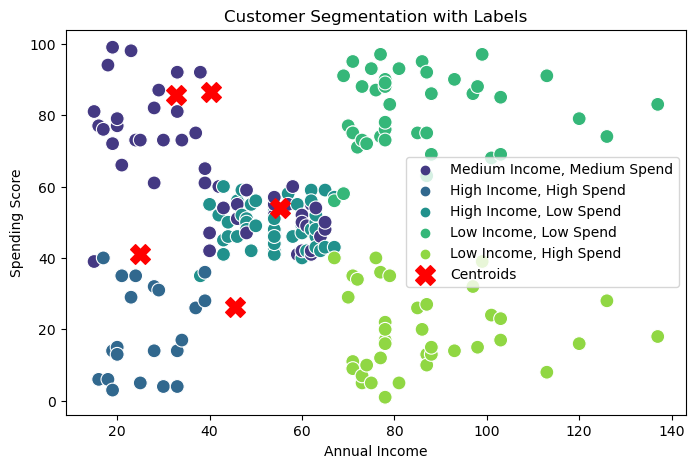

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=df["Customer Type"], palette="viridis", s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],  # Rescale centers
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c="red", marker="X", label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation with Labels")
plt.legend()
plt.show()

# Q8.Write about different parameters in KElbowvisualizer

In [53]:
pip install yellowbrick

     -------------------------------------- 282.6/282.6 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [54]:
from yellowbrick.cluster import KElbowVisualizer

In [60]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10), metric="distortion", timings=True)

C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it 

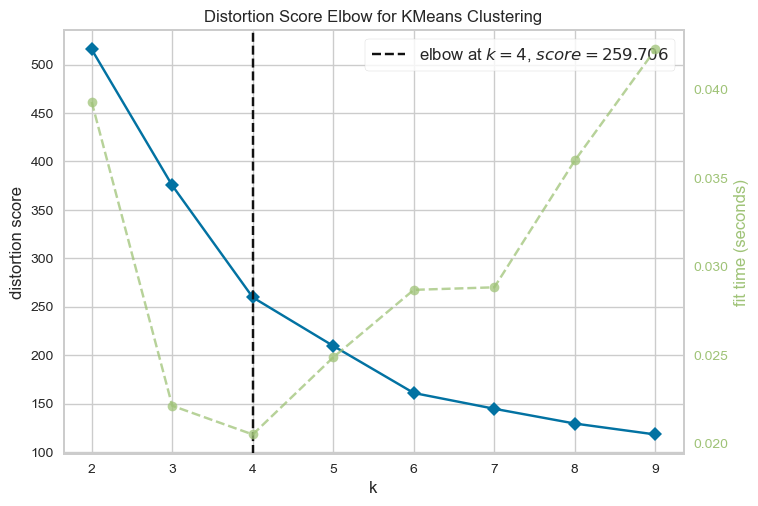

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [61]:
visualizer.fit(X_scaled)  
visualizer.show()

The KElbowVisualizer from the Yellowbrick library helps determine the optimal number of clusters in a dataset for clustering algorithms like K-Means. Key parameters include:

model: The clustering algorithm (e.g., KMeans).
k: The range of cluster numbers to evaluate.
metric: The metric used to assess clustering quality, like "distortion", "silhouette", or "calinski_harabasz".
timings: Whether to display the computation time for each K value.
locate_elbow: Automatically detects the elbow point in the graph.
ax: Matplotlib axes for plotting. This tool helps visualize the "elbow" point, where the

# Q10. what are the disadvantages of DBSCAN 


DBSCAN (Density-Based Spatial Clustering of Applications with Noise) has several disadvantages. It requires careful selection of two parameters: eps (neighborhood radius) and min_samples (minimum points in a cluster), which can be difficult to tune. The algorithm struggles with clusters of varying densities, potentially misclassifying less dense clusters or noise. DBSCAN's computational complexity can be high, especially for large datasets, and its performance degrades in high-dimensional spaces due to the curse of dimensionality. Additionally, it may misidentify boundary points as noise, leading to inaccurate clustering. Overall, while DBSCAN is useful for density-based clustering, it has limitations in handling diverse data structures and large, high-dimensional datasets.

In [46]:
from sklearn.cluster import DBSCAN

In [47]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
df["Cluster"] =dbscan.fit_predict(X_scaled)

In [48]:
df["Cluster"].unique()

array([-1,  0,  2,  1,  3,  4,  5], dtype=int64)

In [50]:
df["Cluster"].count()

200

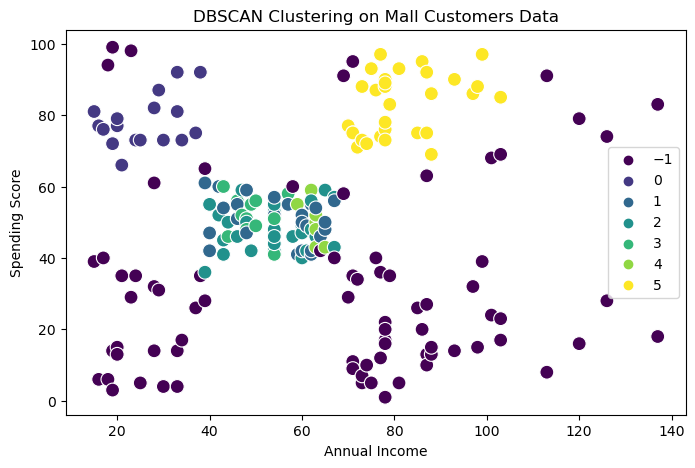

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=df["Cluster"], palette="viridis", s=100)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering on Mall Customers Data")
plt.legend()
plt.show()

# 